In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [4]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [5]:
# reload load_cluster_data
import load_cluster_data
reload (load_cluster_data)

<module 'load_cluster_data' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/load_cluster_data.py'>

In [6]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [7]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 2 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., # karin had 0.65 
    "pi_prior" : 1.
}

print(hypers["eta"])

cuda
0.5


### load_cluster_data takes ~ 5 minutes for ss2 brain data.... 

In [8]:
#cell_types = ['Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte',
#       'Brain_Non-Myeloid_oligodendrocyte',
#       'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_neuron',
#       'Brain_Non-Myeloid_oligodendrocyte_precursor_cell',
#       'Brain_Non-Myeloid_brain_pericyte', 'Brain_Myeloid_macrophage']
#print(cell_types)

In [9]:
# this folder contains input data for each tissue cell type sample
#input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/'

#final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
#    input_folder = input_files_folder, has_genes="yes", celltypes=cell_types) 

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/
Finished reading in data from folder ...
['Limb_Muscle_mesenchymal_stem_cell' 'Limb_Muscle_macrophage'
 'Limb_Muscle_skeletal_muscle_satellite_cell'
 'Limb_Muscle_endothelial_cell' 'Limb_Muscle_B_cell' 'Limb_Muscle_T_cell']
1090
37197
                                             cell_id  Cluster  Cluster_Counts  \
0  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      109              28   
1  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      201              13   
2  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      201              13   
3  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      333             286   
4  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      333             286   

             junction_id gene_id  junc_count  \
0    1_78658103_78663140   Acsl3          28   
1  1_183316702_183318811    Aida           4   
2  1_183318934_18

In [10]:
len(final_data.junction_id_index.unique())

37198

In [11]:
junction_ids_conversion.head()

,junction_id_index,junction_id,Cluster,gene_id
61238,0,10_100080130_100080856,66807,Kitl
777684,1,10_100080130_100087346,66807,Kitl
61239,2,10_100080940_100087346,66807,Kitl
61240,3,10_100087456_100088152,66808,Kitl
2774034,4,10_100087456_100089195,66808,Kitl


In [12]:
print(final_data.cell_type.unique())

['Limb_Muscle_skeletal_muscle_satellite_cell' 'Limb_Muscle_macrophage'
 'Limb_Muscle_endothelial_cell' 'Limb_Muscle_mesenchymal_stem_cell'
 'Limb_Muscle_B_cell' 'Limb_Muscle_T_cell']


In [13]:
print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))

The number of junctions is:  37198
The number of intron clusters observed is:  9679
The number of genes is:  6877


In [14]:
final_data.shape

(6034621, 8)

In [15]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [16]:
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type
0,0,14,65.0,81,16.0,0.802469,A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...,Limb_Muscle_skeletal_muscle_satellite_cell
1,0,15,8.0,81,73.0,0.098765,A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...,Limb_Muscle_skeletal_muscle_satellite_cell
2,0,16,8.0,81,73.0,0.098765,A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...,Limb_Muscle_skeletal_muscle_satellite_cell
3,0,17,2.0,82,80.0,0.024390,A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...,Limb_Muscle_skeletal_muscle_satellite_cell
4,0,18,80.0,82,2.0,0.975610,A1-B002765-3_38_F-1-1_Limb_Muscle_skeletal_mus...,Limb_Muscle_skeletal_muscle_satellite_cell


In [17]:
# save final_data file for sophia here /gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/
#output='/gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/final_data.csv'
#import gzip
#with gzip.open(output + '.gz', mode='wt', encoding='utf-8') as f:
#        final_data.to_csv(f, index=False, sep="}")

# save junction_ids_conversion file for sophia here /gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/
#output='/gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/junction_ids_conversion.csv'
#with gzip.open(output + '.gz', mode='wt', encoding='utf-8') as f:
#        junction_ids_conversion.to_csv(f, index=False, sep="}")

# now do the same for cell_ids_conversion 
#output='/gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/cell_ids_conversion.csv'
#with gzip.open(output + '.gz', mode='wt', encoding='utf-8') as f:
#        cell_ids_conversion.to_csv(f, index=False, sep="}")

In [18]:
# save also junction_ids_conversion file for sophia here /gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/
#junction_ids_conversion.to_hdf('/gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/junction_ids_conversion.h5', key='df', mode='w', complevel=9, complib='blosc')
# save also cell_ids_conversion file for sophia here /gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/
#cell_ids_conversion.to_hdf('/gpfs/commons/groups/knowles_lab/Karin/for-sophia/tabula_muris_ss2/cell_ids_conversion.h5', key='df', mode='w', complevel=9, complib='blosc')

In [19]:
junction_ids_conversion

,junction_id_index,junction_id,Cluster,gene_id
61238,0,10_100080130_100080856,66807,Kitl
777684,1,10_100080130_100087346,66807,Kitl
61239,2,10_100080940_100087346,66807,Kitl
61240,3,10_100087456_100088152,66808,Kitl
2774034,4,10_100087456_100089195,66808,Kitl
...,...,...,...,...
1462005,37193,Y_898115_899427,119621,Kdm5d
1462006,37194,Y_898627_899427,119621,Kdm5d
662375,37195,Y_899550_899786,119622,Kdm5d
2474352,37196,Y_899550_900478,119622,Kdm5d


In [20]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
1090
1090


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [21]:
cell_ids_conversion.head()
# what is the breadkdown of cell types in the data 
cell_ids_conversion['cell_type'].value_counts()

Limb_Muscle_skeletal_muscle_satellite_cell    540
Limb_Muscle_mesenchymal_stem_cell             258
Limb_Muscle_endothelial_cell                  141
Limb_Muscle_B_cell                             71
Limb_Muscle_macrophage                         45
Limb_Muscle_T_cell                             35
Name: cell_type, dtype: int64

In [22]:
# set random seed
torch.manual_seed(0)

num_trials = 10 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in
K = 2

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 1090 cells and J = 37198 junctions
Got the initial ELBO ^
ELBO converged @ -400194848.0 CAVI iteration # 18 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1090 cells and J = 37198 junctions
Got the initial ELBO ^
ELBO converged @ -400174912.0 CAVI iteration # 12 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1090 cells and J = 37198 junctions
Got the initial ELBO ^
ELBO converged @ -400208576.0 CAVI iteration # 9 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1090 cells and J = 37198 junctions
Got the initial ELBO ^
ELBO converged @ -400241536.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1090 cells and J = 37198 junctions
Got the initial ELBO ^
ELBO converged @ -400234240.0 CAVI iteration # 7 complete
Finished CAVI!
Initialize VI

### Consensus Clustering

In [23]:
sum_matrices = consensus_clustering(results)

# normalize by number of trials
normalized_matrix = sum_matrices / sum_matrices.max() # taking the sum_matrix and dividing by the max value in the matrix

# get distance metric 
distance_matrix = 1 - normalized_matrix
distance_matrix

Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations


array([[0. , 0.4, 0.7, ..., 0.6, 0.4, 0.5],
       [0.4, 0. , 0.3, ..., 0.4, 0.6, 0.3],
       [0.7, 0.3, 0. , ..., 0.1, 0.9, 0.2],
       ...,
       [0.6, 0.4, 0.1, ..., 0. , 0.8, 0.3],
       [0.4, 0.6, 0.9, ..., 0.8, 0. , 0.7],
       [0.5, 0.3, 0.2, ..., 0.3, 0.7, 0. ]])

In [24]:
# what is the proportion of 0s and 1s in the distance matrix
print("Proportion of 0s in distance matrix: ", np.count_nonzero(distance_matrix == 0) / (distance_matrix.shape[0] * distance_matrix.shape[1]))
print("Proportion of 1s in distance matrix: ", np.count_nonzero(distance_matrix == 1) / (distance_matrix.shape[0] * distance_matrix.shape[1]))

Proportion of 0s in distance matrix:  0.002063799343489605
Proportion of 1s in distance matrix:  0.0010352663917178688


In [25]:
# cluster distance matrix using hierarchical clustering into K clusters 
from sklearn.cluster import KMeans
# Number of clusters
num_clusters = 10 

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters)
cluster_labels = kmeans.fit_predict(distance_matrix)

# Your N by K matrix
n_by_k_matrix = np.zeros((distance_matrix.shape[0], num_clusters))

# Fill the N by K matrix with cluster assignments
for i in range(num_clusters):
    n_by_k_matrix[:, i] = (cluster_labels == i).astype(int)

In [26]:
# sample 5200 indices from distance matrix
samp_indices = np.random.choice(cell_ids_conversion.shape[0], 1000, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_types_heatmap.cell_type.values

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

n_by_k_matrix = n_by_k_matrix.T
n_by_k_matrix[:, samp_indices]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

[Text(1, 0.5, '9'),
 Text(1, 1.5, '8'),
 Text(1, 2.5, '3'),
 Text(1, 3.5, '0'),
 Text(1, 4.5, '1'),
 Text(1, 5.5, '6'),
 Text(1, 6.5, '2'),
 Text(1, 7.5, '7'),
 Text(1, 8.5, '4'),
 Text(1, 9.5, '5')]

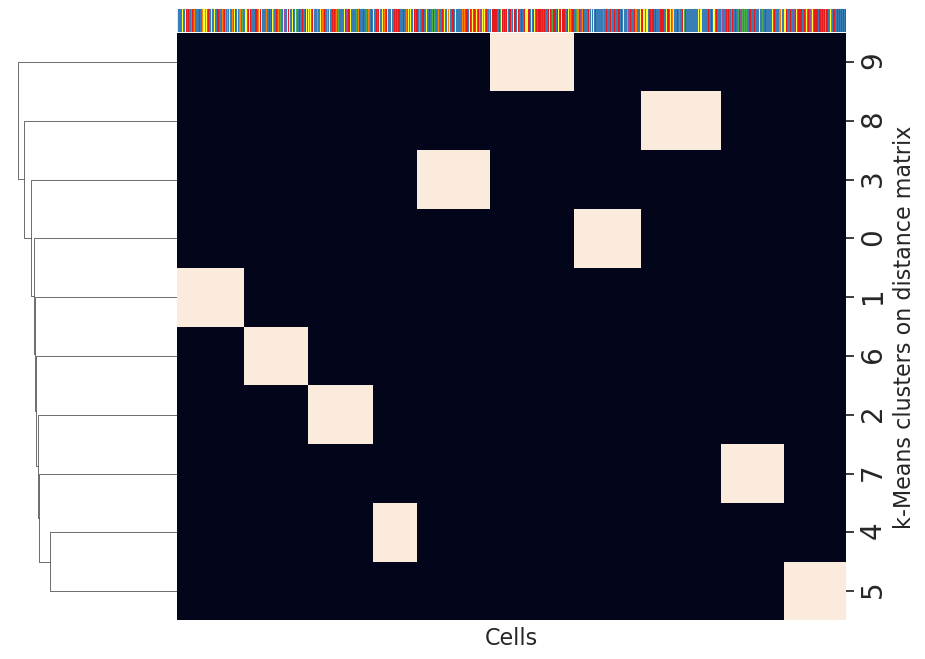

In [27]:
# draw clustermap of sampled_distance_matrix
# Create a clustermap with row colors representing cell types

clustmap = sns.clustermap(
    data=n_by_k_matrix[:, samp_indices],
    method='complete',
    annot=False,
    fmt=".2f",
    xticklabels=False,
    yticklabels=True,
    col_colors=col_colors, 
    figsize=(9, 8))

clustmap.cax.set_visible(False)  # This line hides the colorbar

# dont plot column dendrogram
clustmap.ax_col_dendrogram.set_visible(False)

# xaxis label should be Cluster from k-means on distance matrix
clustmap.ax_heatmap.set_xlabel('Cells', fontsize = 16)
clustmap.ax_heatmap.set_ylabel('k-Means clusters on distance matrix', fontsize = 16)

# increase font size of xticklabels
clustmap.ax_heatmap.set_xticklabels(clustmap.ax_heatmap.get_xmajorticklabels(), fontsize = 20)
# increase font size of yticklabels
clustmap.ax_heatmap.set_yticklabels(clustmap.ax_heatmap.get_ymajorticklabels(), fontsize = 20)

In [28]:
# After the clustermap plotting
for cell_type, color in cell_type_colors.items():
    print(cell_type, color)

Limb_Muscle_mesenchymal_stem_cell (0.8941176470588236, 0.10196078431372549, 0.10980392156862745)
Limb_Muscle_skeletal_muscle_satellite_cell (0.21568627450980393, 0.49411764705882355, 0.7215686274509804)
Limb_Muscle_macrophage (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)
Limb_Muscle_T_cell (0.596078431372549, 0.3058823529411765, 0.6392156862745098)
Limb_Muscle_B_cell (1.0, 0.4980392156862745, 0.0)
Limb_Muscle_endothelial_cell (1.0, 1.0, 0.2)


In [29]:
cell_type_colors

{'Limb_Muscle_mesenchymal_stem_cell': (0.8941176470588236,
  0.10196078431372549,
  0.10980392156862745),
 'Limb_Muscle_skeletal_muscle_satellite_cell': (0.21568627450980393,
  0.49411764705882355,
  0.7215686274509804),
 'Limb_Muscle_macrophage': (0.30196078431372547,
  0.6862745098039216,
  0.2901960784313726),
 'Limb_Muscle_T_cell': (0.596078431372549,
  0.3058823529411765,
  0.6392156862745098),
 'Limb_Muscle_B_cell': (1.0, 0.4980392156862745, 0.0),
 'Limb_Muscle_endothelial_cell': (1.0, 1.0, 0.2)}

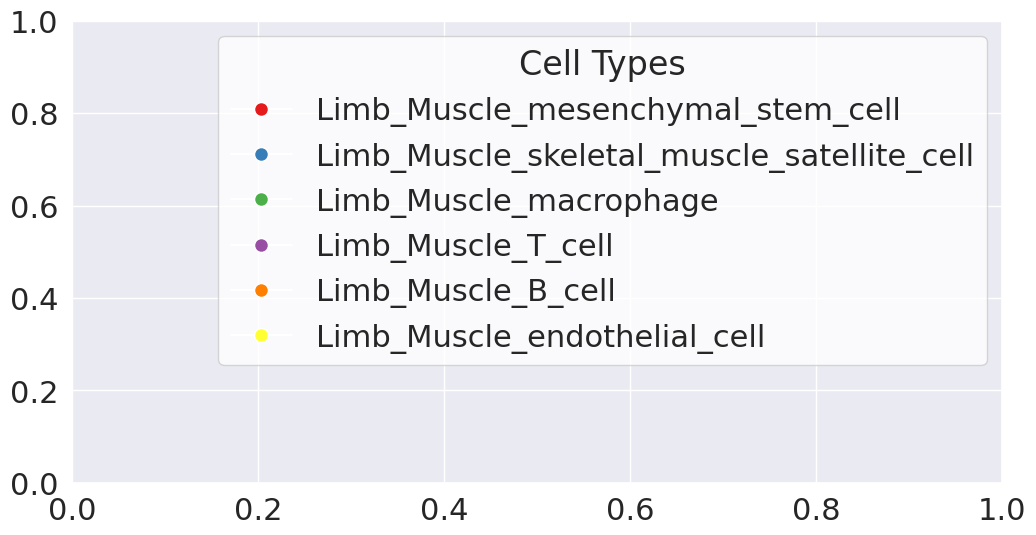

In [30]:
# Add a custom legend for row cell types
# make size bigger plt.fig size
plt.figure(figsize=(12,6))

legend_labels = cell_type_colors.keys()
legend_colors = cell_type_colors.values()

# Make the font of legend larger 
sns.set(font_scale=2)

custom_legend = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color) for label, color in zip(legend_labels, legend_colors)]
legend = plt.legend(handles=custom_legend, title='Cell Types', frameon=True)
legend.get_frame().set_facecolor('white')

In [31]:
legend_labels

dict_keys(['Limb_Muscle_mesenchymal_stem_cell', 'Limb_Muscle_skeletal_muscle_satellite_cell', 'Limb_Muscle_macrophage', 'Limb_Muscle_T_cell', 'Limb_Muscle_B_cell', 'Limb_Muscle_endothelial_cell'])

In [32]:
legend_colors

dict_values([(0.8941176470588236, 0.10196078431372549, 0.10980392156862745), (0.21568627450980393, 0.49411764705882355, 0.7215686274509804), (0.30196078431372547, 0.6862745098039216, 0.2901960784313726), (0.596078431372549, 0.3058823529411765, 0.6392156862745098), (1.0, 0.4980392156862745, 0.0), (1.0, 1.0, 0.2)])

In [33]:
cell_types_heatmap.cell_type.value_counts()

Limb_Muscle_skeletal_muscle_satellite_cell    492
Limb_Muscle_mesenchymal_stem_cell             239
Limb_Muscle_endothelial_cell                  132
Limb_Muscle_B_cell                             66
Limb_Muscle_macrophage                         39
Limb_Muscle_T_cell                             32
Name: cell_type, dtype: int64

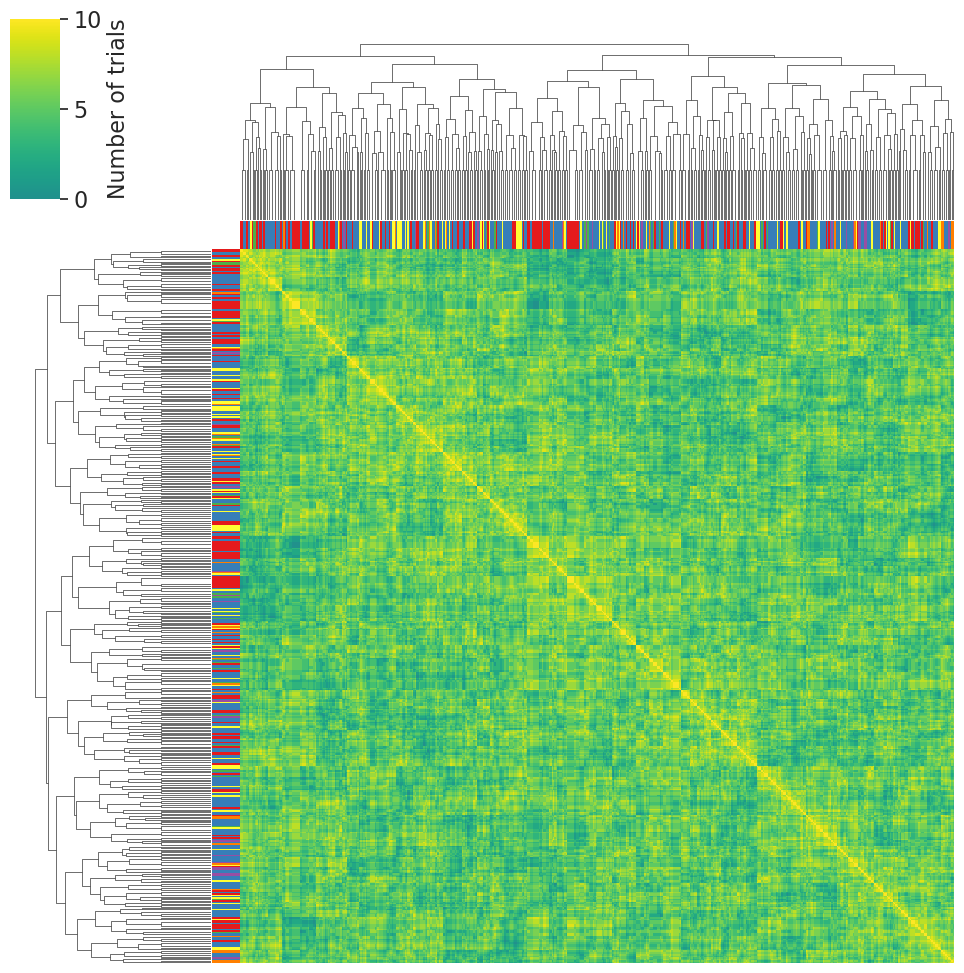

In [34]:
# make also a clustermap of sum_matrices along with their cell types 
# sample 5200 indices from distance matrix
samp_indices = np.random.choice(cell_ids_conversion.shape[0], 500, replace=False)
cell_types_heatmap = cell_ids_conversion.iloc[samp_indices]

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_heatmap['cell_type'].unique()))

# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_heatmap['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_heatmap.cell_type.values

# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=sum_matrices[samp_indices,:][:,samp_indices],
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 10),
    center=0,
    row_colors=row_colors,  # Apply row colors
    col_colors=col_colors,   # Apply column colors
        cbar_kws={'label': 'Number of trials'} # Split label over two lines here
    )

cluster.cax.set_ylabel('Number of trials', size=16)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(16)

plt.show()

/scratch/ipykernel_119412/679672602.py:4: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


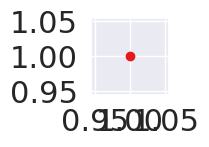

In [35]:
# show the colour 
col =(0.8941176470588236, 0.10196078431372549, 0.10980392156862745)
plt.figure(figsize=(1,1))
plt.scatter(1, 1, c=col)
plt.show()

In [36]:
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_type_colors

{'Limb_Muscle_skeletal_muscle_satellite_cell': (0.8941176470588236,
  0.10196078431372549,
  0.10980392156862745),
 'Limb_Muscle_mesenchymal_stem_cell': (0.21568627450980393,
  0.49411764705882355,
  0.7215686274509804),
 'Limb_Muscle_endothelial_cell': (0.30196078431372547,
  0.6862745098039216,
  0.2901960784313726),
 'Limb_Muscle_T_cell': (0.596078431372549,
  0.3058823529411765,
  0.6392156862745098),
 'Limb_Muscle_B_cell': (1.0, 0.4980392156862745, 0.0),
 'Limb_Muscle_macrophage': (1.0, 1.0, 0.2)}

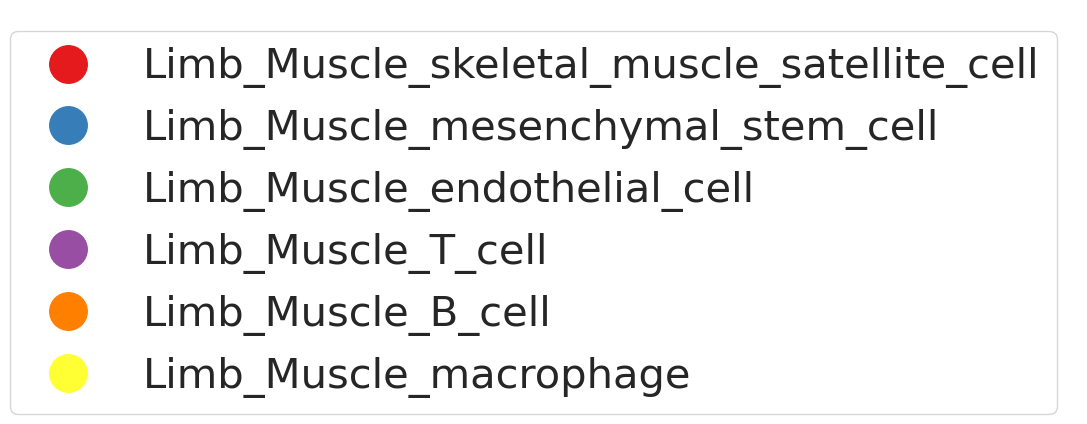

In [37]:
# Create the legend
# make background white 
sns.set_style("white")
# Create the legend
# Create the legend
for cell_type, color in cell_type_colors.items():
    # Extract name after "Myeloid_"
    display_name = cell_type.split("Myeloid_")[-1] if "Myeloid_" in cell_type else cell_type
    plt.plot([], [], 'o', label=display_name, color=color, markersize=27)  # Use 'o' to show the colors clearly

plt.legend(fontsize=30)
plt.axis('off')  # Turn off axis
plt.show()

### Evaluate the learned posteriors

The trial with the highest ELBO was 1


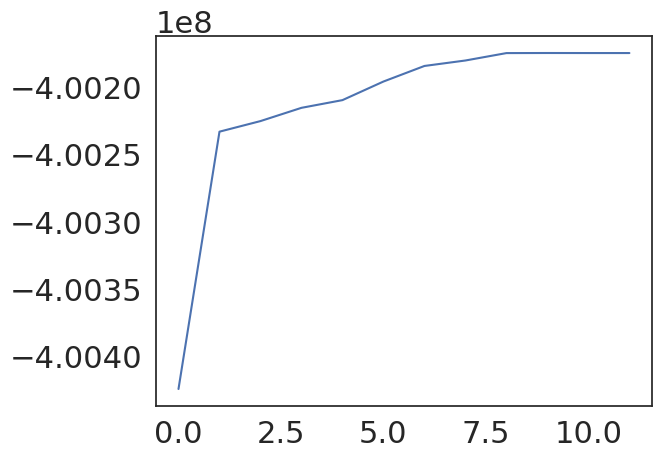

In [38]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [39]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

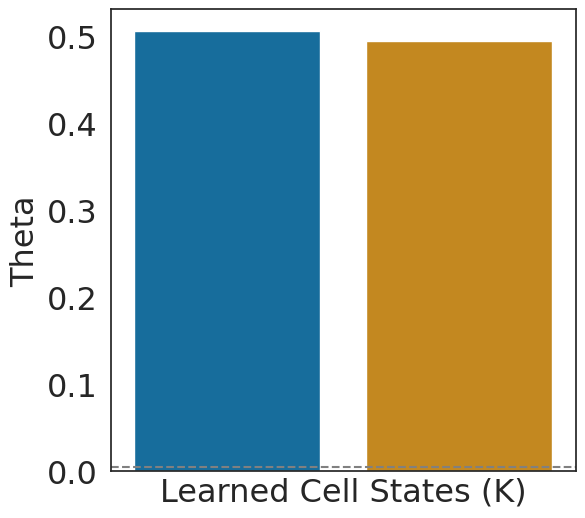

In [40]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot.head()

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.005, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [41]:
GAMMA_f_plot.head()

,theta,cell_state,new_cell_state
1,0.505498,1,0
0,0.494502,0,1


In [42]:
final_data.cell_type.unique()

array(['Limb_Muscle_skeletal_muscle_satellite_cell',
       'Limb_Muscle_macrophage', 'Limb_Muscle_endothelial_cell',
       'Limb_Muscle_mesenchymal_stem_cell', 'Limb_Muscle_B_cell',
       'Limb_Muscle_T_cell'], dtype=object)

                                    cell_type  count  percentage
0  Limb_Muscle_skeletal_muscle_satellite_cell    540    0.495413
1           Limb_Muscle_mesenchymal_stem_cell    258    0.236697
2                Limb_Muscle_endothelial_cell    141    0.129358
3                          Limb_Muscle_B_cell     71    0.065138
4                      Limb_Muscle_macrophage     45    0.041284
5                          Limb_Muscle_T_cell     35    0.032110


(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6')])

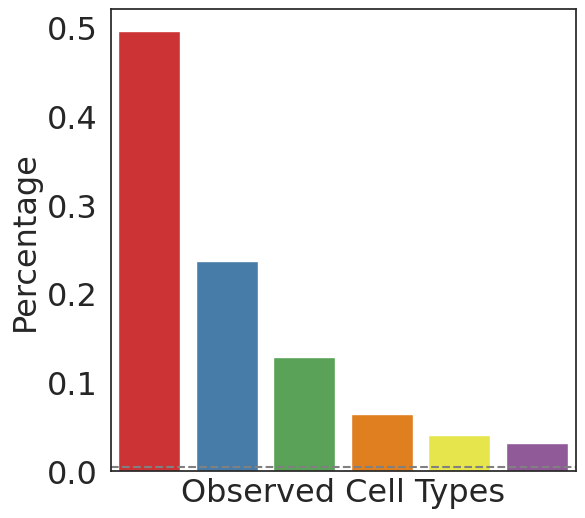

In [43]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']
# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)
# plot barplot similar to above with thetas 

color_order = [cell_type_colors[cell_type] for cell_type in cell_types_summary['cell_type']]

# Create the barplot using the cell_type_colors palette
plt.figure(figsize=(6, 6))
sns.barplot(x="cell_type", y="percentage", data=cell_types_summary, palette=color_order)
plt.axhline(0.005, ls='--', color='grey')
plt.ylabel("Percentage", fontsize=23)
plt.xlabel("Observed Cell Types", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)

In [44]:
# let's retain only the cell states that are used more than 1% of the time
GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.005]
GAMMA_f_plot.index.values

array([1, 0])

In [45]:
color_order

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
 (1.0, 0.4980392156862745, 0.0),
 (1.0, 1.0, 0.2),
 (0.596078431372549, 0.3058823529411765, 0.6392156862745098)]

In [46]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,1,0
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
1085,0.0,1.0
1086,1.0,0.0
1087,0.0,1.0
1088,1.0,0.0


In [47]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_119412/1031914918.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_1,CellState_2
cell_type,,
Limb_Muscle_B_cell,25.000000,46.000000
Limb_Muscle_T_cell,13.000000,22.000000
Limb_Muscle_endothelial_cell,56.000000,85.000000
Limb_Muscle_macrophage,19.000000,26.000000
Limb_Muscle_mesenchymal_stem_cell,158.000000,100.000000
Limb_Muscle_skeletal_muscle_satellite_cell,279.998627,260.001373


In [48]:
PHI_f.shape # 29 cell states kept 

(1090, 4)

/scratch/ipykernel_119412/2359410869.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_119412/2359410869.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


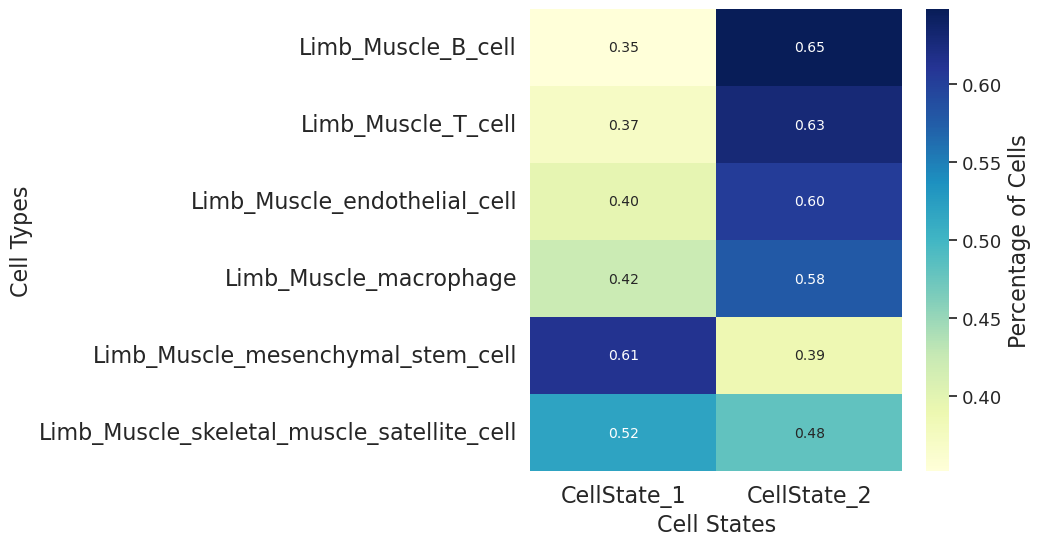

In [49]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(6, 6))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

ax = sns.heatmap(sum_prop, annot=True, cmap="YlGnBu", fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': 'Percentage of Cells'})

labels = [label.get_text().replace("oligodendrocyte_precursor_cell", "oligodendrocyte_\nprecursor_cell") for label in ax.get_yticklabels()]
ax.set_yticklabels(labels)

# Further visual modifications
xlabel = plt.xlabel("Cell States", fontsize=16)
ylabel = plt.ylabel("Cell Types", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjusting color bar settings
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=13)
cbar.set_ylabel('Percentage of Cells', fontsize=16)

plt.show()

In [50]:
# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

{'CellState_1': ('Limb_Muscle_mesenchymal_stem_cell', 0.612), 'CellState_2': ('Limb_Muscle_B_cell', 0.648)}


In [51]:
# run fisher's exact test to see if the cell states are enriched for any cell types
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
2179,P9-D042186-3_8_M-1-1_Limb_Muscle_B_cell,Limb_Muscle_B_cell,CellState_2,1.0
1088,P9-B002769-3_39_F-1-1_Limb_Muscle_T_cell,Limb_Muscle_T_cell,CellState_1,1.0
2177,P9-B002765-3_38_F-1-1_Limb_Muscle_macrophage,Limb_Muscle_macrophage,CellState_2,1.0
1086,P8-D042473-3_10_M-1-1_Limb_Muscle_B_cell,Limb_Muscle_B_cell,CellState_1,1.0
2175,P8-D042186-3_8_M-1-1_Limb_Muscle_T_cell,Limb_Muscle_T_cell,CellState_2,1.0


In [52]:
# run fisher's exact test to test overall association between cell states and cell types
# contingency table

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(PHI_f_melt['variable'], PHI_f_melt['cell_type'])
contingency_table

chi2, pvalue, _, _ = chi2_contingency(contingency_table)
print(chi2, pvalue)
print(print("P-value: {:.50f}".format(pvalue)))

29.22991427652412 2.0899422301900522e-05
P-value: 0.00002089942230190052188036446689789471520271035843
None


In [53]:
# change column names to only include cell type the thing aftert 'Myeloid_'
contingency_table.columns = ['_'.join(x.split('_')[2:]) for x in contingency_table.columns]
contingency_table

,B_cell,T_cell,endothelial_cell,macrophage,mesenchymal_stem_cell,skeletal_muscle_satellite_cell
variable,,,,,,
CellState_1,25,13,56,19,158,280
CellState_2,46,22,85,26,100,260


In [54]:
# convert contingency table to proportions 
contingency_table = contingency_table / contingency_table.sum() # represents proportion of cells in cell type that is in cell state 
contingency_table

,B_cell,T_cell,endothelial_cell,macrophage,mesenchymal_stem_cell,skeletal_muscle_satellite_cell
variable,,,,,,
CellState_1,0.352113,0.371429,0.397163,0.422222,0.612403,0.518519
CellState_2,0.647887,0.628571,0.602837,0.577778,0.387597,0.481481


In [55]:
# reorder variable in contingency table cellstate10 should go after cellstate9
contingency_table = contingency_table.reindex(sorted(contingency_table.columns), axis=1)

# Assuming your dataframe is called df
ordered_indices = [
    'CellState_1', 'CellState_2', 'CellState_3', 'CellState_4',
    'CellState_5', 'CellState_6', 'CellState_7', 'CellState_8',
    'CellState_9', 'CellState_10'
]

contingency_table = contingency_table.reindex(ordered_indices)
contingency_table

,B_cell,T_cell,endothelial_cell,macrophage,mesenchymal_stem_cell,skeletal_muscle_satellite_cell
variable,,,,,,
CellState_1,0.352113,0.371429,0.397163,0.422222,0.612403,0.518519
CellState_2,0.647887,0.628571,0.602837,0.577778,0.387597,0.481481
CellState_3,NaN,NaN,NaN,NaN,NaN,NaN
CellState_4,NaN,NaN,NaN,NaN,NaN,NaN
CellState_5,NaN,NaN,NaN,NaN,NaN,NaN
CellState_6,NaN,NaN,NaN,NaN,NaN,NaN
CellState_7,NaN,NaN,NaN,NaN,NaN,NaN
CellState_8,NaN,NaN,NaN,NaN,NaN,NaN
CellState_9,NaN,NaN,NaN,NaN,NaN,NaN


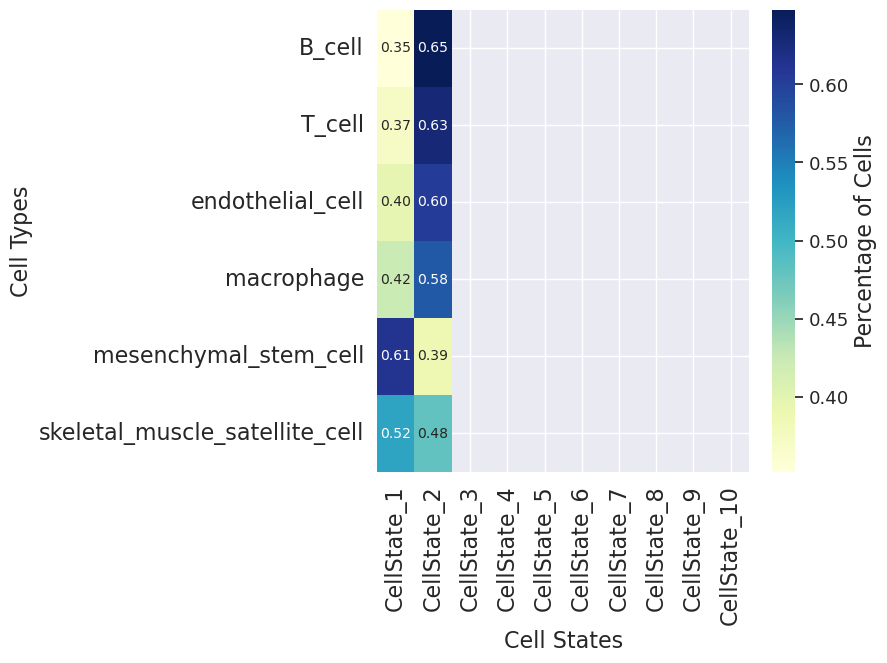

In [56]:
plt.figure(figsize=(6,6))
ax = sns.heatmap(contingency_table.T, annot=True, cmap="YlGnBu", fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': 'Percentage of Cells'})

# Modifying the label for better visual
labels = [label.get_text().replace("oligodendrocyte_precursor_cell", "oligodendrocyte_\nprecursor_cell") for label in ax.get_yticklabels()]
ax.set_yticklabels(labels)

# Further visual modifications
xlabel = plt.xlabel("Cell States", fontsize=16)
ylabel = plt.ylabel("Cell Types", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adjusting color bar settings
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=13)
cbar.set_ylabel('Percentage of Cells', fontsize=16)

plt.show()


FloatingPointError: NaN dissimilarity value.

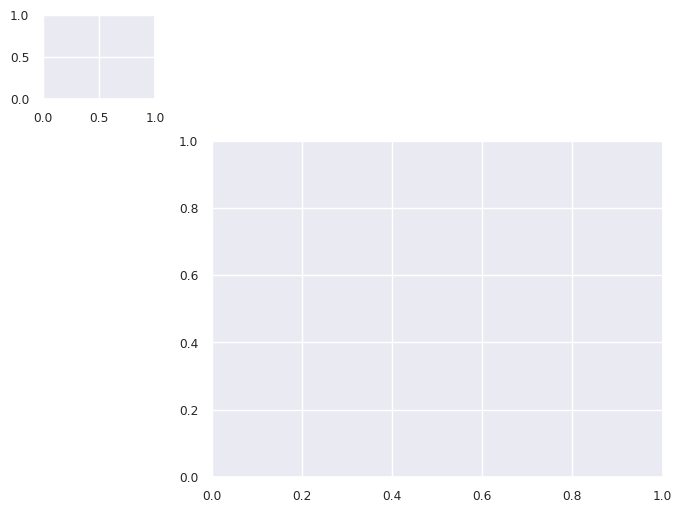

In [57]:
contingency_table

# plot clustermap of contingency table
g = sns.clustermap(contingency_table.T, cmap="YlGnBu", figsize=(8, 6), annot=True, fmt='.2f', annot_kws={"size": 10}, cbar_kws={'label': '% of cells'})
# Increase the font size of the x-axis and y-axis tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=12) # Set x-axis label size
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12) # Set y-axis label size
# remove x lab 
g.ax_heatmap.set_xlabel("")

# Save the figure to a PDF file
plt.savefig("clustermap.pdf", bbox_inches='tight')

## Do differential junction analysis 

In [ ]:
# plot histogram of observed junction usage ratios
plt.figure(figsize=(5, 5))
# make background white
sns.set_style("white")
plt.hist(final_data['juncratio'], bins=50, color='green')
plt.xlabel("Observed PSI", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid()
plt.show()

In [ ]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
juncs_probs.shape

In [ ]:
alpha_plus_pi = ALPHA_f+PI_f
alpha_plus_pi.shape

In [ ]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

In [ ]:
plt.figure(figsize=(5, 5))
# Plot the values
plt.hist(filtered_values.numpy(), bins=20)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=20)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=20)  
# Increase tick label size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# add grid 
plt.grid()

In [ ]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col+1) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [ ]:
# calculate sd deviation for each junction for cell states 0 to 19 
juncs_probs_df["sd"] = juncs_probs_df.iloc[:,0:K].std(axis=1)

In [ ]:
juncs_probs_df

In [ ]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

In [ ]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"].values))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"].values 
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"].values < 0.05, "yes", "no")

In [ ]:
scores_all_juncs_df

In [ ]:
scores_all_juncs_df.sort_values(by="score")

In [ ]:
c_test=junction_ids_conversion[junction_ids_conversion["junction_id_index"]==3925].Cluster
print(c_test)

In [ ]:
# diff spliced junctions just for microglia cell states 0 and 1
scores_microglia = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [0,4]]
    b = PI_f[junc_index, [0,4]]
    scores_microglia.append(score(a, b).item())

scores_microglia_df = pd.DataFrame(scores_microglia, columns = ["score"])
scores_microglia_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_microglia_df.sort_values(by="score", ascending=False).head(10)
scores_microglia_df = scores_microglia_df.merge(junction_ids_conversion, on="junction_id_index").sort_values(by="score", ascending=False)
scores_microglia_df["logistic_score"] = 1 / (1 + np.exp(-scores_microglia_df["score"]))

# Compute the Bayesian q-value for FDR
scores_microglia_df["q_value"] = 1 - scores_microglia_df["logistic_score"]
scores_microglia_df["significance"] = np.where(scores_microglia_df["q_value"] < 0.05, "yes", "no")

In [ ]:
scores_microglia_df.iloc[886]

In [ ]:
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index").sort_values(by="score", ascending=False)

In [ ]:
def quick_junc_plot(junc, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["junction_id_index"] == junc]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Junction:" + str(junc) + " Gene: " + simple_data_junc["gene_id"].values[0])
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [ ]:
def quick_clust_plot(clust, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    # how many cells from each cell type? let's only keep cell types with more than 10 cells here otherwise violin plot doesn't make sense
    # Modify y-tick labels to show only the portion after "Myeloid_" and split "oligodendrocyte_precursor_cell" over two lines

    # set figure size to be 6 by 7 
    plt.figure(figsize=(6, 6))
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Cluster:" + str(clust) + " Gene: " + simple_data_junc["gene_id"].values[0], fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    # increase font size of title and xaxis and yaxis labels
    plt.xlabel("Observed PSI", fontsize=16)
    
    # Modify y-tick labels to show only the portion after "Myeloid_"
    current_labels = [label.get_text() for label in plt.gca().get_yticklabels()]
    new_labels = [label.split("Myeloid_")[-1] if "Myeloid_" in label else label for label in current_labels]
    new_labels = [label.replace("oligodendrocyte_precursor_cell", "oligodendrocyte_\nprecursor_cell") for label in new_labels]
    plt.yticks(plt.yticks()[0], new_labels, fontsize=20)
    plt.ylabel("Cell Type", fontsize=20)
    plt.xlabel("Observed PSI", fontsize=20)
    # increase font size of xticks and yticks
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=16)
    plt.show()

In [ ]:
simple_data = final_data[["cell_id_index", "cell_type", "junction_id_index", "junc_count", "cluster_count"]]
simple_data = simple_data.merge(junction_ids_conversion, on="junction_id_index")
simple_data["junc_ratio"] = simple_data["junc_count"] / simple_data["cluster_count"]
simple_data.head()

In [ ]:
simple_data[simple_data["Cluster"]== 5903].junction_id.unique()

In [ ]:
# add percentile rank of score for each junction
scores_all_juncs_df["percentile_rank"] = scores_all_juncs_df["score"].rank(pct=True)
scores_all_juncs_df

In [ ]:
scores_all_juncs_df[scores_all_juncs_df["Cluster"] == 8680]

In [ ]:
# colour by cell_type
simple_data[simple_data["junction_id_index"] == 6124].cell_type.value_counts()
# make histogram of junc_ratio and colour by cell_type
sns.histplot(data=simple_data[simple_data["junction_id_index"] == 6124], x="junc_ratio", hue="cell_type", bins=20)

In [ ]:
# check wd 
os.getcwd()

In [ ]:
# generate PSI table from simple_data_junc for just junction_id_index 548
simple_data_junc_548 = simple_data_junc[simple_data_junc["junction_id_index"] == 548]
# save this table as a csv file to plot on top of umap 
simple_data_junc_548.to_csv("simple_data_junc_548.csv")

# generate PSI table from simple_data_junc for just junction_id_index 549
simple_data_junc_549 = simple_data_junc[simple_data_junc["junction_id_index"] == 549]
# save this table as a csv file to plot on top of umap
simple_data_junc_549.to_csv("simple_data_junc_549.csv")

In [ ]:
# rename junc_ratio column to 548_junc_ratio
simple_data_junc_548.rename(columns={'junc_ratio':'548_junc_ratio'}, inplace=True)
# do the same for 549
simple_data_junc_549.rename(columns={'junc_ratio':'549_junc_ratio'}, inplace=True)

In [ ]:
# extract just cell_id_index, cell_type and 548_junc_ratio
simple_data_junc_548 = simple_data_junc_548[["cell_id_index", "cell_type", "548_junc_ratio"]]
# do the same for 549
simple_data_junc_549 = simple_data_junc_549[["cell_id_index", "cell_type", "549_junc_ratio"]]
# merge the two tables together
simple_data_junc_548_549 = simple_data_junc_548.merge(simple_data_junc_549, on=["cell_id_index", "cell_type"])
simple_data_junc_548_549.head()

In [ ]:
# save to file
simple_data_junc_548_549.to_csv("simple_data_junc_548_549.csv")
simple_data_junc_548_549

In [ ]:
simple_data_junc.junction_id.unique()

In [ ]:
simple_data_junc[simple_data_junc["cell_type"].isin(["Brain_Myeloid_macrophage", "Brain_Non-Myeloid_endothelial_cell"])].cluster_count.hist(bins=50)

In [ ]:
# Assuming you have significance data in scores_all_juncs_df
significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "yes"]["score"]
not_significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "no"]["score"]

plt.figure(figsize=(7, 6))

# Plot histograms
plt.hist(significant, bins=10, label='Significant', log=True, alpha=0.4)
plt.hist(not_significant, bins=10, label='Not Significant', log=True, alpha=0.7)

# Adjust labels, legend, and ticks
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=15)

plt.show()


In [ ]:
# only show scores for junctions that had decent certainty for ALPHA+BETA  
# turn alpha_plus_pi into dataframe 
alpha_plus_pi_df = pd.DataFrame(alpha_plus_pi, columns = range(K))
alpha_plus_pi_df["junction_id_index"] = alpha_plus_pi_df.index
# now melt alpha_plus_pi_df 
alpha_plus_pi_df_melt = pd.melt(alpha_plus_pi_df, id_vars=['junction_id_index'], value_vars=alpha_plus_pi_df.columns[:-1])
# rename columns to be "cell_state" and "alpha_plus_pi"
alpha_plus_pi_df_melt.columns = ["junction_id_index", "cell_state", "alpha_plus_pi"]
alpha_plus_pi_df_melt.head()

In [ ]:
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

In [ ]:
# find the 10th, 20th, 30th... percentiels of alpha_plus_pi
alpha_plus_pi_df_melt["percentile_rank"] = alpha_plus_pi_df_melt["alpha_plus_pi"].rank(pct=True)
# subset dataframe to include only junctions with alpha_plus_pi >= 10
alpha_plus_pi_df_melt = alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["alpha_plus_pi"] >= 50]
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

In [ ]:
scores_all_juncs_df = scores_all_juncs_df[scores_all_juncs_df["junction_id_index"].isin(alpha_plus_pi_df_melt.junction_id_index.unique())]

In [ ]:
# make a histogram of the scores_all_juncs_df
plt.figure(figsize=(5, 5))
plt.hist(scores_all_juncs_df["score"], bins=10, color="purple", log=True)
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)
# add grid 
plt.grid()

In [ ]:
marker_genes = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_marker_genes.csv', index_col=0)
# name first column gene_id 
marker_genes.columns = ["gene_id", "cell_type"]
marker_genes.head()

In [ ]:
# get top 10% scoring junctions in scores_all_juncs_df 
top10perc = scores_all_juncs_df[scores_all_juncs_df["percentile_rank"] >= 0.9]
print("The number of junctions in the top 10% is: ", top10perc.shape[0])
# how many of them are in genes that appear in the marker_genes dataframe
top10perc = top10perc.merge(marker_genes, on="gene_id")
print("The number of junctions in the top 10% that are in marker genes is: ", top10perc.shape[0])

In [ ]:
115/1620

In [ ]:
# make a version of the plot that shows that learned junction proportions across cell states 
from scipy.stats import beta

def quick_posterior_junc_plot(junc, ALPHAs, PIs, cell_states=None):
    
    junc_a = ALPHAs[junc, ]
    junc_b = PIs[junc, ]

    if cell_states:
        junc_a = junc_a[cell_states]
        junc_b = junc_b[cell_states]

    # Define a list of colors for the plot
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Add more colors if needed

    # Create a figure and axis for the plot with size 6x6
    fig, ax = plt.subplots(figsize=(5, 5))

    print(junc_a, junc_b)
    
    # Loop through each cell state and plot its beta distribution with a unique color
    for j, (a, b) in enumerate(zip(junc_a, junc_b)):
        
        x = np.linspace(beta.ppf(0.01, a, b),
                        beta.ppf(0.99, a, b), 100)
        
        color = colors[j % len(colors)]  # Cycle through colors if more cell states than colors
        label = f'Cell State {j + 1}'
        
        ax.plot(x, beta.pdf(x, a, b),
                color + '-', lw=2, alpha=0.6, label=label)
        
    # Add labels and legend with increased font size
    ax.set_xlabel('PSI', fontsize=20)
    ax.set_ylabel('Probability Density', fontsize=20)
    ax.set_title('Beta Distributions for junction ' + str(junc), fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Place the legend to the right of the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    plt.grid()
    plt.show()


In [ ]:
scores_microglia_df = scores_microglia_df[scores_microglia_df["junction_id_index"].isin(alpha_plus_pi_df_melt.junction_id_index.unique())]
scores_microglia_df.head()

In [ ]:
scores_microglia_df[scores_microglia_df["gene_id"] == "App"]

In [ ]:
quick_posterior_junc_plot(886, ALPHA_f, PI_f, cell_states=[0,4])


In [ ]:
alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["junction_id_index"] == 6917]

In [ ]:
quick_junc_plot(6917, simple_data)

In [ ]:
quick_posterior_junc_plot(6917, ALPHA_f, PI_f)

In [ ]:
quick_posterior_junc_plot(548, ALPHA_f, PI_f)

In [ ]:
PHI_f

In [ ]:
simple_data_junc_548_549
# add cell_id to simple_data_junc_548_549 
simple_data_junc_548_549 = simple_data_junc_548_549.merge(cell_ids_conversion, on="cell_id_index")
# remove cell_type_x column and rename cell_type_y to cell_type
simple_data_junc_548_549.drop(columns=["cell_type_x"], inplace=True)
simple_data_junc_548_549.rename(columns={"cell_type_y":"cell_type"}, inplace=True)
simple_data_junc_548_549.head()
# save to file
simple_data_junc_548_549.to_csv("simple_data_junc_548_549.csv")

In [ ]:
# save cell assignments to file for downstream analysis
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/'

# BBmixture model cell assignments
output_file = os.path.join(output_dir, 'Leaflet_BBmixture.csv')
PHI_f.to_csv(output_file, index=True, header=True)
print('Saved Leaflet latent cell states to {}'.format(output_file))